# Nowcasting Autoencoder Tutorial - Pytorch Lightning Version

This tutorial extends the basic AutoEncoder example by demonstrating a simplified training loop by making use of PyTorch Lightning. 

In [66]:
import datetime
import functools

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot

In [62]:
import xarray as xr


In [89]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import pyearthtools.training as pettrain

In [64]:
from pyearthtools.data.time import Petdt

In [7]:
my_site = 'site_archive_jasmin'  # set this to 'site_archive_nci', 'site_archive_jasmin' or 'site_archive_met_office'
import importlib
_ = importlib.import_module(my_site)

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/ssde/j25b/mohc_shared/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/ssde/j25b/mohc_shared/dscop/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/ssde/j25b/mohc_shared/dscop/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25b/mohc_shared/mh_pet/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25b/mohc_shared/mh_pet/ra22_himawari', 'Rainfields3': '/gws/ssde/j25b/mohc_shared/mh_pet/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer', 'ew4_merra2_meteo': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_meteo', 'ew4_merra2_aero': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_aerosols/3d', 'ew4_mtg_li': '/gws/nopw/j04/ew4energy/MTG_LI/', 'ew4_era5': '/gws/nopw/j04/ew4energy/ERA5/tutorial_202606'}


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

In [24]:
import pytorch_lightning as pl

In [10]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Load and prepare data

To load and prepare the data, we will use the PyEarthTools site accessor, and then build a pipeline with the data accessor to do the necessary transforms to prepare the data for training an autoencoder.

PyEarthTools API docs
* [Data API Index](https://pyearthtools.readthedocs.io/en/latest/api/data/data_index.html)
* [Archive Index Class docs](https://pyearthtools.readthedocs.io/en/latest/api/data/data_api.html#pyearthtools.data.indexes.ArchiveIndex)
* [Example ERA5 accessor](https://pyearthtools.readthedocs.io/en/latest/api/data/data_api.html#pyearthtools.data.download.weatherbench.WB2ERA5)

In [11]:
# We specify the date, hour, and minute for querying data
selected_date = '20210609T02:00'

In [12]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

We can start with a simple pipeline and then demonstrate how to use it.

In [13]:
satpipe = petpipe.Pipeline(
    himawari
)

In [14]:
himawari_sample = satpipe[selected_date]
himawari_sample

<xarray.Dataset> Size: 31MB
Dimensions:                    (time: 1, latitude: 1726, longitude: 2214)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T02:00:00
  * latitude                   (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                  (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 31MB dask.array<chunksize=(1, 1726, 2214), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:08 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

### Defining the pipeline
Now we will add in all the processing steps we need, including:
* order the coordinates to be suitable and optimised to accessed by the iterator.
* Select a subset based on latitude and longitude
* Convert to numpy
* specify the range an iterator on the pipeline should walkthrough

PyEarthools API Docs
* [Pipeline Class](https://pyearthtools.readthedocs.io/en/latest/api/pipeline/pipeline_api.html#pyearthtools.pipeline.Pipeline)
* [Pipeline operations docs](https://pyearthtools.readthedocs.io/en/latest/api/pipeline/pipeline_api.html#pipeline-operations)

In [93]:
himawari = petdata.archive.Himawari('surface_global_irradiance')



In [94]:
# We will try to predict one-hour jumps
temporal_window = petpipe.modifications.TemporalWindow(
    prior_indexes=[-1], 
    posterior_indexes=[0], 
    merge_method = functools.partial(xr.concat, dim='time'),
    timedelta=petdata.time.TimeDelta((20, "minutes"))
)



In [95]:
training_split = petpipe.iterators.DateRange('20200101T00', '20210101T00', interval='10 minutes')
val_split = petpipe.iterators.DateRange('20201101T00', '20210301T00', interval='10 minutes')


In [68]:
xarray_steps = petpipe.Pipeline(
    himawari,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    temporal_window,
    iterator=training_split,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError    
)



In [69]:
numpy_conversion = petpipe.Pipeline(
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=training_split,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

numpy.float32

In [185]:
class ToTensor(petpipe.Operation):
    def __init__(self, recognised_types=None):
        # super().__init__()
        super().__init__(recognised_types=recognised_types)
        self.dtype=np.float32

    def apply_func(self, sample):
        converted_sample = (
            torch.from_numpy(self.dtype(sample[0])),
            torch.from_numpy(self.dtype(sample[0])),
        )
        return converted_sample

    def undo_func(self, sample):
        undone_sample = (
            sample[0].numpy(),
            sample[1].numpy(),
        )
        return undone_sample


In [186]:
tensor_conversion = petpipe.Pipeline(
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    ToTensor(),
    iterator=training_split,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

In [187]:
fullsat = xarray_steps + tensor_conversion
fullsat

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [189]:
fullsat[selected_date][0].dtype

torch.float32

### Data Exploration
Lets take a look at what the dataset contains. For this purpose we will create a smaller pipeline that keeps the data in xarray for easier plotting.

TypeError: torch._VariableFunctionsClass.from_numpy() takes no keyword arguments

In [78]:
xarray_steps[selected_date][0]

<xarray.Dataset> Size: 2MB
Dimensions:                    (time: 1, latitude: 501, longitude: 601)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T01:40:00
  * latitude                   (latitude) float32 2kB -35.0 -34.98 ... -25.0
  * longitude                  (longitude) float32 2kB 138.0 138.0 ... 150.0
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 2MB dask.array<chunksize=(1, 501, 601), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:07 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

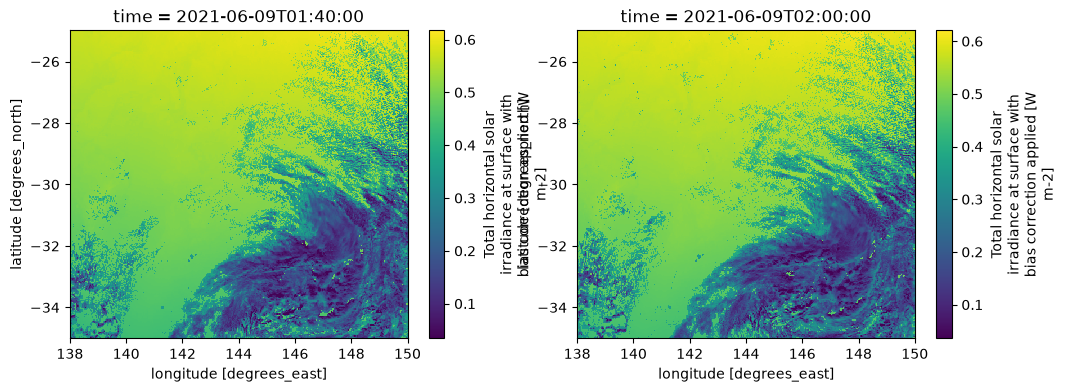

In [85]:
fig1 = matplotlib.pyplot.figure(figsize=(12,4))
ax1 = fig1.add_subplot(1,2,1,title='himawari input image')
xarray_steps[selected_date][0]['surface_global_irradiance'][0,:,:].plot.imshow()
ax1 = fig1.add_subplot(1,2,2,title='himawari target image')
xarray_steps[selected_date][1]['surface_global_irradiance'][0,:,:].plot.imshow()

## Training a machine learning model
Now that we have loaded and prepared the data, we can train a machine learning model on the data using the pipeline to feed the data into the training algorithm. In this example we will use an autoencoder, which is an example of unsupervised training as we don't need to label the data.

### Define the Autoencoder architecture - Pytorch Lightning
Here we define an **AutoEncoder**, as in the other autoencoder tutorials. However in this case we will define the same architecture using the additiona fuctionality of pytorch lightning. 

Further reading
* [Building a Pytorch Lightning Model](https://lightning.ai/docs/pytorch/stable/reference/model/train_model_basic)
* [Converting from PyTorch to PyTorch Lightning](https://lightning.ai/pages/community/tutorial/from-pytorch-to-pytorch-lighting-getting-started-guide/)

In [56]:
class Era5AutoencoderTrainer(pl.LightningModule):
    def __init__(self, 
                 input_height = 501,
                 input_width = 601,
                 kernel_size = 4,
                 stride=2,
                 input_channel_count = 2,
                 output_channel_count = 2,
                 latent_dim=300):
        super().__init__()

        self.input_width = input_width
        self.input_height = input_height
        self.input_channel_count = input_channel_count
        self.output_channel_count = output_channel_count

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=self.input_channel_count, out_channels=16, kernel_size=kernel_size, stride = stride, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride =stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=7),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=stride, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=self.output_channel_count, kernel_size=kernel_size, stride=stride, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
        self.criterion = nn.L1Loss(),

    def configure_optimizers(self):
        self.optimizer=optim.Adam(self.parameters(), lr=1e-3),
        return self.optimizer

    def forward(self, x):

        # Get latent representation
        latent = self.encoder(x)

        # Reconstruct input
        reconstructed = self.decoder(latent)

        return reconstructed

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = self.criterion(outputs, labels)
        return loss




Initialize the LightningModule and LightningDataModule

In [86]:
auteconder_model = Era5AutoencoderTrainer(
    input_channel_count=1, 
    output_channel_count=1,
)


In [97]:
training_split, val_split

(DateRange
 	Initialisation                 DateRange Iterator
 		 allowlist                      None
 		 blocklist                      None
 		 end                            '20210101T00'
 		 interval                       '10 minutes'
 		 start                          '20200101T00',
 DateRange
 	Initialisation                 DateRange Iterator
 		 allowlist                      None
 		 blocklist                      None
 		 end                            '20210301T00'
 		 interval                       '10 minutes'
 		 start                          '20201101T00')

In [170]:
batch_size=4

In [ ]:
# Initialise the lightning data module for training
data_module = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    fullsat,    # Data preparation pipeline
    train_split=train_split,    # Training data split
    valid_split=val_split,      # Validation data split
    batch_size=batch_size,      # Batch size for training
    num_workers=n_workers,      
    multiprocessing_context="forkserver",  
    persistent_workers=True     # Keep workers alive between epochs
)

### Prediction from untrained Autoencoder - and an aside on CPUs and GPUs
Here we revisit how if we make a prediction before training, using randomly initialised weights, we get noise out. This informs intuition on how machine learning works - by comparing poor predictions to the expected outputs, and iteratively solving towards an effective network.

These code snippets also demonstrate how we move the data into the GPU memory in order to do inference on the GPU, and then move it back to the CPU to analyse it further. In some architectures, the model layers are even split across CPU and GPU to make maximum use of GPU memory for high-cost layer calculations.

In [190]:
trainer = pl.Trainer(accelerator='gpu',devices=1)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [191]:
trainer.fit(auteconder_model, iter(fullsat))

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Sequential │  105 K │ train │     0 │
│ 1 │ decoder │ Sequential │  105 K │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 210 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 210 K                                                                                                
Total estimated model params size (MB): 0.842                                                                      
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

TypeError: 'tuple' object is not callable

In [85]:
# Loss function and optimizer


def train(debug=True, num_epochs=1, max_samples=10, print_per=20):
    """
    Main Training loop Function
    """
    sample_ix = 0 
    batch_size = 1  # Todo - batches not yet supported
    
    
    for epoch in range(num_epochs):
        print(f'current epoch {epoch+1}')
        total_loss = 0    
        epoch_samples = 0
        training_iterator = iter(fullsat)  # Make an iterator to walk the time period
    
        while True:
            try:
                sample = next(training_iterator)
            except StopIteration:
                print('stop')
                break  # advance the epoch loop
            except:
                print('error - general')
                pass # some samples are just missing
    
            sample_ix += batch_size
            epoch_samples += batch_size
            if epoch_samples % print_per == 0:
                print(epoch_samples)
            
            if sample_ix > max_samples:
                print('exceeded max samples')
                break

            if debug:
                print(sample_ix)
    
            x = torch.from_numpy(sample).float().to(device)   

            if torch.any(torch.isnan(x)):
                # Skip nan inputs, they break the training
                # print('skipping nans')
                continue
                
            if debug:
                print("Input")
                print(x)
    
            optimizer.zero_grad()
    
            # Forward pass
            y = model.forward(x)

            if debug:
                print("prediction")
                print(y)
            
            loss = criterion(y, x)
            if debug:
                print("loss")
                print(loss)
    
            # Backward pass and optimize        
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        # Print epoch statistics
        if epoch_samples != 0:
            avg_loss = total_loss / epoch_samples
            print(f'Epoch [{epoch+1}/{epoch_samples}], Average Loss: {avg_loss:.4f}')
        else:
            print('no samples processed this epoch')

In [ ]:
%%time
train(debug=False, num_epochs=3, max_samples=15 * 1000, print_per = 500, batch_size=1)

current epoch 1
500


### Make predictions and Evaluating Outputs
Once the model is trained, we now make predictions and evaluate the model.

In [49]:
fullsat_validate = petpipe.Pipeline(
    satpipe,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20210101T00', '20220101T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

In [50]:
validate_iterator = iter(fullsat_validate)

In [51]:
prediction_from_iterator(validate_iterator, model)

array([[[[0.50066555, 0.48923492, 0.5044858 , ..., 0.50488853,
          0.49451387, 0.49649027],
         [0.49090624, 0.48472565, 0.49744317, ..., 0.49654698,
          0.4855185 , 0.49566448],
         [0.5052452 , 0.49125722, 0.506305  , ..., 0.5060132 ,
          0.49593255, 0.49208266],
         ...,
         [0.50569075, 0.49159238, 0.50625706, ..., 0.5070591 ,
          0.49621794, 0.4921509 ],
         [0.49466854, 0.48274335, 0.49927363, ..., 0.49906513,
          0.49090406, 0.4949398 ],
         [0.49666557, 0.49339545, 0.49257937, ..., 0.4921879 ,
          0.49162406, 0.4860889 ]]]],
      shape=(1, 1, 501, 601), dtype=float32)

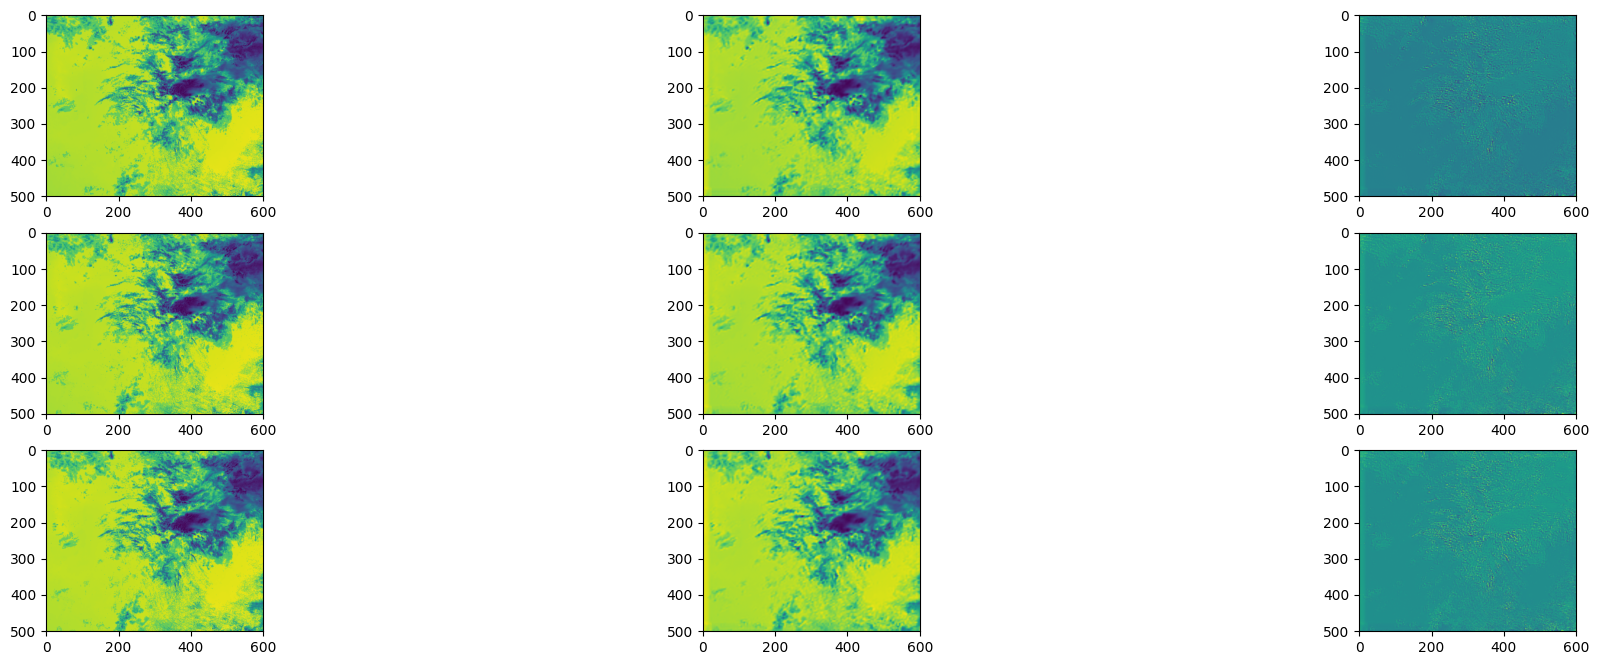

In [52]:
fig1 = plt.figure('sidebyside_satellite', figsize=(24,8))
for ix1 in range(3):
    sample_numpy = next(validate_iterator)
    sample_gpu = torch.from_numpy(sample_numpy).float().to(device)
    prediction_gpu = model.forward(sample_gpu)
    prediction_cpu = prediction_gpu.to('cpu').detach().numpy()
    ax1 = fig1.add_subplot(3,3,(ix1*3)+1)
    ax1.imshow(sample_numpy[0,0])
    ax1 = fig1.add_subplot(3,3,(ix1*3)+2)
    ax1.imshow(prediction_cpu[0,0])
    ax1 = fig1.add_subplot(3,3,(ix1*3)+3)
    ax1.imshow(prediction_cpu[0,0] - sample_numpy[0,0])    

# Calculate scores for predictions
In order to evaluate the model performance, we need to use some metrics that capture different aspects of accuracy. Since we are generating images, we will use various state of the art image-related metrics. 

Furthe reading:
* [Guide to metrics for images generated by ML models](https://huggingface.co/blog/PrunaAI/objective-metrics-for-image-generation-assessment)
* torch metrics
   * [Structural Similarity Index](https://lightning.ai/docs/torchmetrics/stable/image/structural_similarity.html) - Aiming to measure how well the image strcuture is captured
   * [RMSE Sliding Window](https://lightning.ai/docs/torchmetrics/stable/image/root_mean_squared_error_using_sliding_window.html)Look at RMSE, but not just point by point

In [53]:
import torchmetrics.image

In [54]:
ssi_metric = torchmetrics.image.StructuralSimilarityIndexMeasure()

In [55]:
rmse_sw_metric = torchmetrics.image.RootMeanSquaredErrorUsingSlidingWindow()

In [56]:
ssi_values = []
rmse_values = []
for ix1 in range(10):
    sample_numpy = next(validate_iterator)
    sample_cpu = torch.from_numpy(sample_numpy).float()
    sample_gpu = sample_cpu.to(device)
    prediction_gpu = model.forward(sample_gpu)
    prediction_cpu_tensor = prediction_gpu.to('cpu').detach()
    
    ssi_values += [float(ssi_metric(sample_cpu,  prediction_cpu_tensor)) ]
    rmse_values += [float(rmse_sw_metric(sample_cpu,  prediction_cpu_tensor))]

In [57]:
ssi_values

[0.599666953086853,
 0.5938255190849304,
 0.6057079434394836,
 0.5808976292610168,
 0.5494664907455444,
 0.5597828030586243,
 0.5347251892089844,
 0.5212662220001221,
 0.510153591632843,
 0.4967922866344452]

In [58]:
rmse_values

[0.05667933449149132,
 0.06012710556387901,
 0.06275594979524612,
 0.06581048667430878,
 0.0692400112748146,
 0.07177083194255829,
 0.07587534189224243,
 0.07947684079408646,
 0.08317696303129196,
 0.0867389515042305]

### Ideas for extension

* Improved model architecture
  * Compare results for a larger model (more layers, larger latent space)
  * Compare results for different sizes of training dataset
  * Can we incorporate a different loss function more suitable for this application?
* Alternative metrics
  * Are there better ways to measure model performance
* Different datasets
  * Could we use this apporach with other satellite datasets?
  * Could we add more channels?
  * Could we blend with other sources e.g. model data, radar?

### Further reading

* [PyTorch Lightning Autoencoder](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/08-deep-autoencoders.html)
* [PyEarthTools API docs](https://pyearthtools.readthedocs.io/en/latest/api/api.html)
